In [48]:
# Cargar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap  # Crear una paleta de colores personalizada

from sklearn.metrics import (
    confusion_matrix,  # Evaluar aciertos y errores de clasificacion
    roc_curve,  # Calcular los valores para construir la curva ROC
    roc_auc_score  # Calcular el area bajo la curva ROC
)
import sys
from pathlib import Path  # Manejo de rutas de archivo 

#Encontrar la raiz del proyecto
ROOT = Path.cwd()
while not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)) # Encuentra la carpeta src
from src.function_clean import guardar_dataframe, load_data
from src.function_prediction import *

In [49]:
#Cargar modelo
ruta = "../model/modelo_candidato_churn.joblib"
modelo = cargar_modelo(ruta)

In [50]:
# Cargar df
ruta_df_test = "../database/silver/model_data/test_data_customers.csv"
df = load_data(ruta_df_test)

In [51]:
df.isnull().mean().round(4)*100 #validar % de nulls

customer_id_anonymous        0.00
monthly_spend               25.00
total_shipments              0.00
antiguedad_dias              0.00
dias_desde_ultima_compra     3.57
monthly_spend_is_null        0.00
churn_label                  0.00
dtype: float64

In [52]:
# Generar las predicciones para datos de test y visualizar los primeros cinco resultados
df_predict = generar_predicciones(df, modelo)
df_predict.head(5)

,customer_id_anonymous,probabilidad_churn,prediccion_churn,churn_real,resultado,nivel_riesgo,fecha_prediccion,umbral
0,C00056,0.0162,0,0,Correcto,Bajo,2026-07-19,0.5
1,C00104,0.0000,0,0,Correcto,Bajo,2026-07-19,0.5
2,C00002,0.0217,0,0,Correcto,Bajo,2026-07-19,0.5
3,C00101,0.9544,1,1,Correcto,Muy alto,2026-07-19,0.5
4,C00072,0.0000,0,0,Correcto,Bajo,2026-07-19,0.5


In [53]:
# Calcular los valores necesarios para construir la curva ROC
fpr, tpr, thresholds = roc_curve(df_predict[["churn_real"]],df_predict[["prediccion_churn"]])
# Calcular el area bajo la curva ROC usando las probabilidades
auc_roc = roc_auc_score(df_predict[["churn_real"]], df_predict[["prediccion_churn"]])

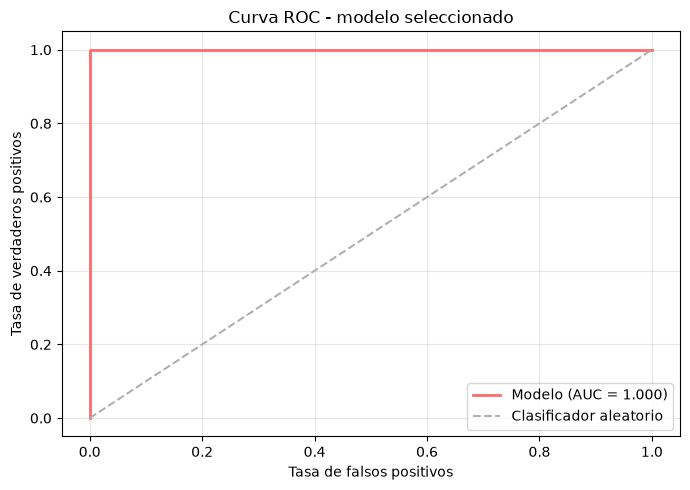

In [54]:
#visualizar resultado de auc_roc
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr,color="#FF6B6B",linewidth=2,label=f"Modelo (AUC = {auc_roc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--",color="#B0B0B0",label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - modelo seleccionado")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La curva ROC presenta un AUC de 1, lo que indica que el modelo logró diferenciar correctamente a los clientes con churn de aquellos sin churn en el conjunto de prueba. Sin embargo, este resultado debe interpretarse con precaución debido al tamaño reducido de la muestra. Por esta razon, es necesario monitorear el desempeño del modelo, generar alertas ante posibles cambios en los resultados y reentrenarlo a medida que se disponga de más datos.

In [55]:
#Matriz de confusion
matriz = confusion_matrix(df_predict[["churn_real"]], df_predict[["prediccion_churn"]])

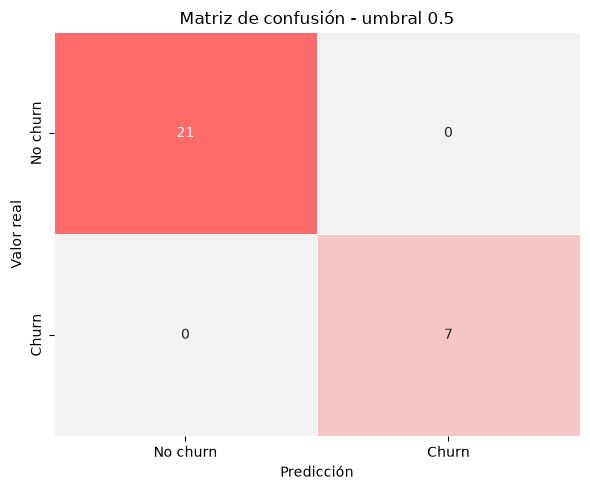

In [56]:
colores = LinearSegmentedColormap.from_list(
    "matriz",
    ["#F2F2F2", "#FF6B6B"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d",cmap=colores,cbar=False,xticklabels=["No churn", "Churn"],yticklabels=["No churn", "Churn"], linewidths=0.5, linecolor="white")
plt.title(f"Matriz de confusión - umbral 0.5")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

In [57]:
# Importancia de variables en el modelo
clasificador = modelo.named_steps["modelo"]

importancias = pd.DataFrame({
    "variable": modelo.features_modelo,
    "importancia": clasificador.feature_importances_
})

importancias = importancias.sort_values(
    "importancia",
    ascending=False
)

importancias

,variable,importancia
1,total_shipments,0.407442
0,monthly_spend,0.262115
3,dias_desde_ultima_compra,0.240466
4,monthly_spend_is_null,0.046574
2,antiguedad_dias,0.043404


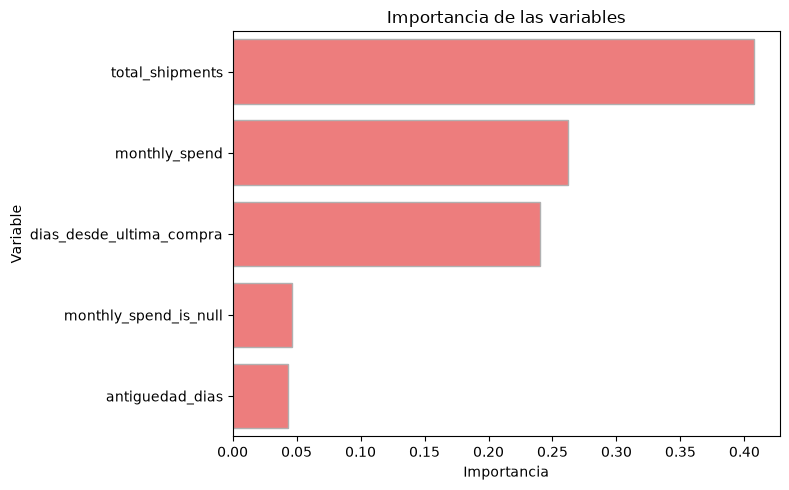

In [58]:
plt.figure(figsize=(8, 5))

sns.barplot(data=importancias, x="importancia",y="variable", color="#FF6B6B", edgecolor="#B0B0B0")
plt.title("Importancia de las variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

total_shipments es la variable con mayor influencia en las predicciones del modelo, con una importancia aproximada del 40,7 %. Le siguen monthly_spend  con 26,2 % y dias_desde_ultima_compra con 24 %. Esto sugiere que el nivel de actividad del cliente, representado por la cantidad de envíos, el tiempo desde su última compra y su gasto mensual, es determinante para identificar el riesgo de abandono. Por otro lado, antiguedad_dias y el indicador de valores nulos en el gasto presentan una menor influencia

In [59]:
#Guardar predicciones
ruta = "../database/gold/predictions_data/predicciones_test_data_customers.csv"
guardar_dataframe(df_predict,ruta)

Archivo guardado correctamente en: ..\database\gold\predictions_data\predicciones_test_data_customers.csv
